In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Ecommerce_Big_Data_Analysis") \
    .getOrCreate()

print("Spark version:", spark.version)

Spark version: 3.5.0


In [3]:
df = spark.read.csv(
    "hdfs://namenode:9000/ecommerce/input/2019-Oct.csv",
    header=True,
    inferSchema=True
)

df.printSchema()

root
 |-- event_time: timestamp (nullable = true)
 |-- event_type: string (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- category_id: long (nullable = true)
 |-- category_code: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- price: double (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- user_session: string (nullable = true)



In [4]:
print("Total records:", df.count())

Total records: 42448764


In [5]:
event_counts = df.groupBy("event_type").count().orderBy("count", ascending=False)

event_counts.show()

+----------+--------+
|event_type|   count|
+----------+--------+
|      view|40779399|
|      cart|  926516|
|  purchase|  742849|
+----------+--------+



In [6]:
category_counts = (
    df.filter(df.category_code.isNotNull())
      .groupBy("category_code")
      .count()
      .orderBy("count", ascending=False)
)

category_counts.show(10, truncate=False)

+--------------------------------+--------+
|category_code                   |count   |
+--------------------------------+--------+
|electronics.smartphone          |11507231|
|electronics.clocks              |1311033 |
|computers.notebook              |1137623 |
|electronics.video.tv            |1113750 |
|electronics.audio.headphone     |1100188 |
|appliances.kitchen.refrigerators|887755  |
|appliances.kitchen.washer       |869404  |
|appliances.environment.vacuum   |801670  |
|apparel.shoes                   |763901  |
|auto.accessories.player         |470208  |
+--------------------------------+--------+
only showing top 10 rows



In [7]:
purchase_products = (
    df.filter(df.event_type == "purchase")
      .groupBy("product_id")
      .count()
      .orderBy("count", ascending=False)
)

purchase_products.show(10)

+----------+-----+
|product_id|count|
+----------+-----+
|   1004856|28944|
|   1004767|21806|
|   1004833|12697|
|   1005115|12543|
|   4804056|12381|
|   1004870|10615|
|   1002544|10549|
|   1004249| 9090|
|   1004836| 7691|
|   1005105| 7293|
+----------+-----+
only showing top 10 rows



In [8]:
from pyspark.sql.functions import avg, round

avg_price_by_event = (
    df.groupBy("event_type")
      .agg(round(avg("price"), 2).alias("average_price"))
      .orderBy("average_price", ascending=False)
)

avg_price_by_event.show()

+----------+-------------+
|event_type|average_price|
+----------+-------------+
|      cart|       333.83|
|  purchase|       309.56|
|      view|       288.98|
+----------+-------------+



In [9]:
from pyspark.sql.functions import to_date

daily_events = (
    df.withColumn("event_date", to_date("event_time"))
      .groupBy("event_date", "event_type")
      .count()
      .orderBy("event_date")
)

daily_events.show(10)

+----------+----------+-------+
|event_date|event_type|  count|
+----------+----------+-------+
|2019-10-01|  purchase|  19307|
|2019-10-01|      cart|  16658|
|2019-10-01|      view|1208280|
|2019-10-02|  purchase|  19469|
|2019-10-02|      cart|  17268|
|2019-10-02|      view|1154591|
|2019-10-03|  purchase|  19255|
|2019-10-03|      view|1088725|
|2019-10-03|      cart|  19323|
|2019-10-04|      cart|  43829|
+----------+----------+-------+
only showing top 10 rows



In [10]:
daily_pivot = (
    daily_events
    .groupBy("event_date")
    .pivot("event_type", ["view", "cart", "purchase"])
    .sum("count")
    .orderBy("event_date")
)

daily_pivot.show(10)

+----------+-------+-----+--------+
|event_date|   view| cart|purchase|
+----------+-------+-----+--------+
|2019-10-01|1208280|16658|   19307|
|2019-10-02|1154591|17268|   19469|
|2019-10-03|1088725|19323|   19255|
|2019-10-04|1346320|43829|   27041|
|2019-10-05|1271348|35497|   23494|
|2019-10-06|1264062|32146|   22171|
|2019-10-07|1161101|18052|   21378|
|2019-10-08|1329119|18442|   23072|
|2019-10-09|1306363|18432|   22748|
|2019-10-10|1243087|18997|   21993|
+----------+-------+-----+--------+
only showing top 10 rows



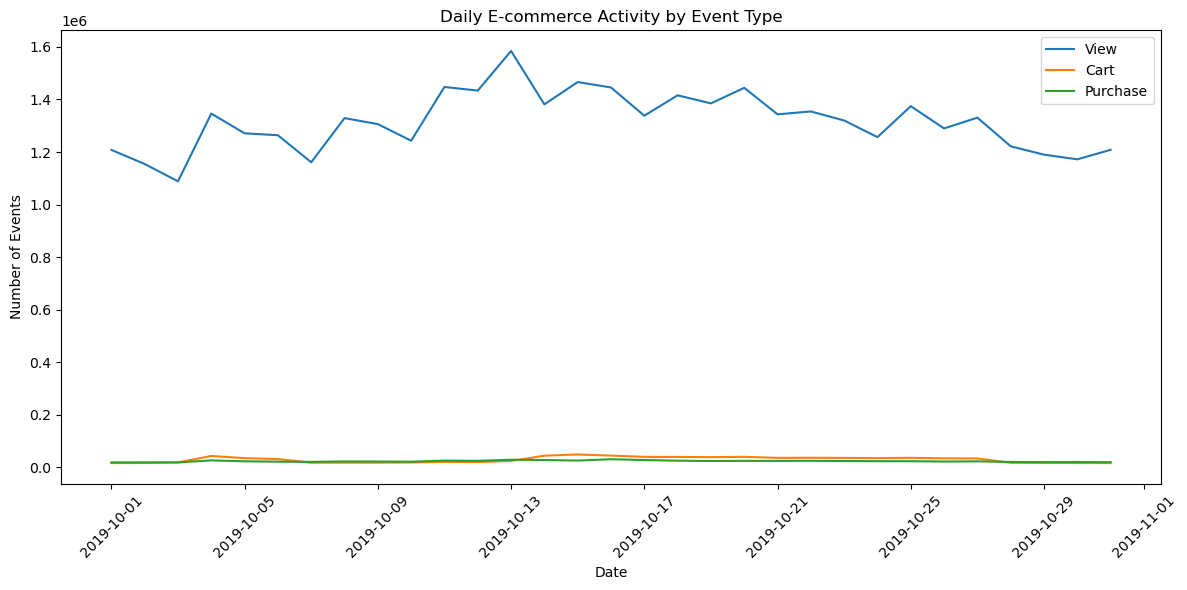

In [11]:
import matplotlib.pyplot as plt

plot_data = daily_pivot.toPandas()

plt.figure(figsize=(12, 6))
plt.plot(plot_data["event_date"], plot_data["view"], label="View")
plt.plot(plot_data["event_date"], plot_data["cart"], label="Cart")
plt.plot(plot_data["event_date"], plot_data["purchase"], label="Purchase")

plt.xlabel("Date")
plt.ylabel("Number of Events")
plt.title("Daily E-commerce Activity by Event Type")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

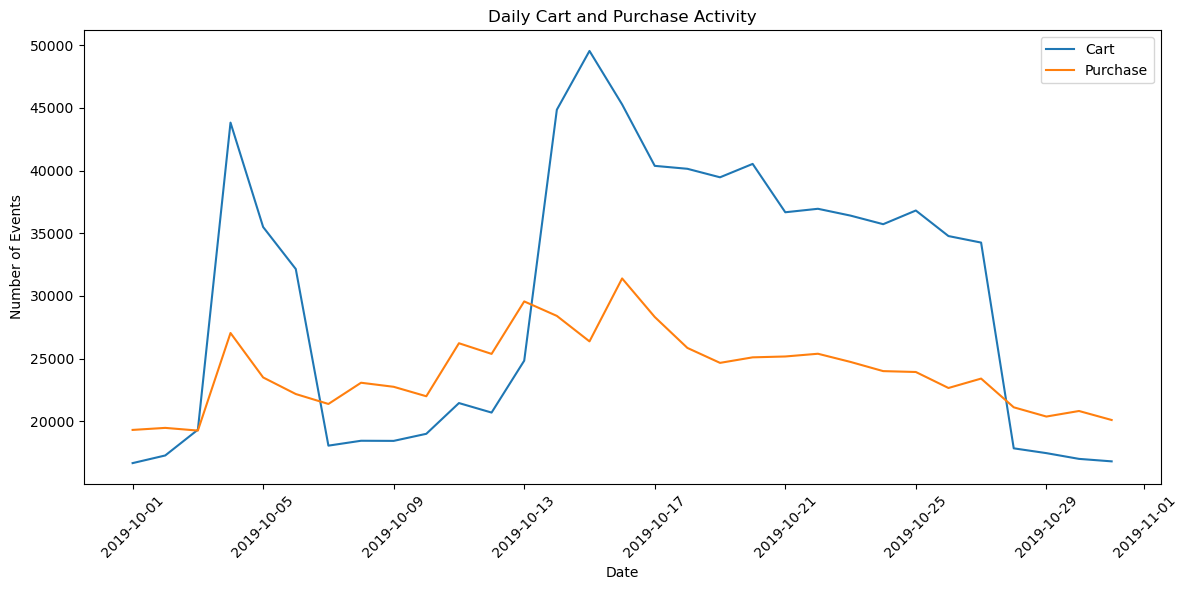

In [12]:
import matplotlib.pyplot as plt

cart_purchase = plot_data[["event_date", "cart", "purchase"]]

plt.figure(figsize=(12, 6))
plt.plot(cart_purchase["event_date"], cart_purchase["cart"], label="Cart")
plt.plot(cart_purchase["event_date"], cart_purchase["purchase"], label="Purchase")

plt.xlabel("Date")
plt.ylabel("Number of Events")
plt.title("Daily Cart and Purchase Activity")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

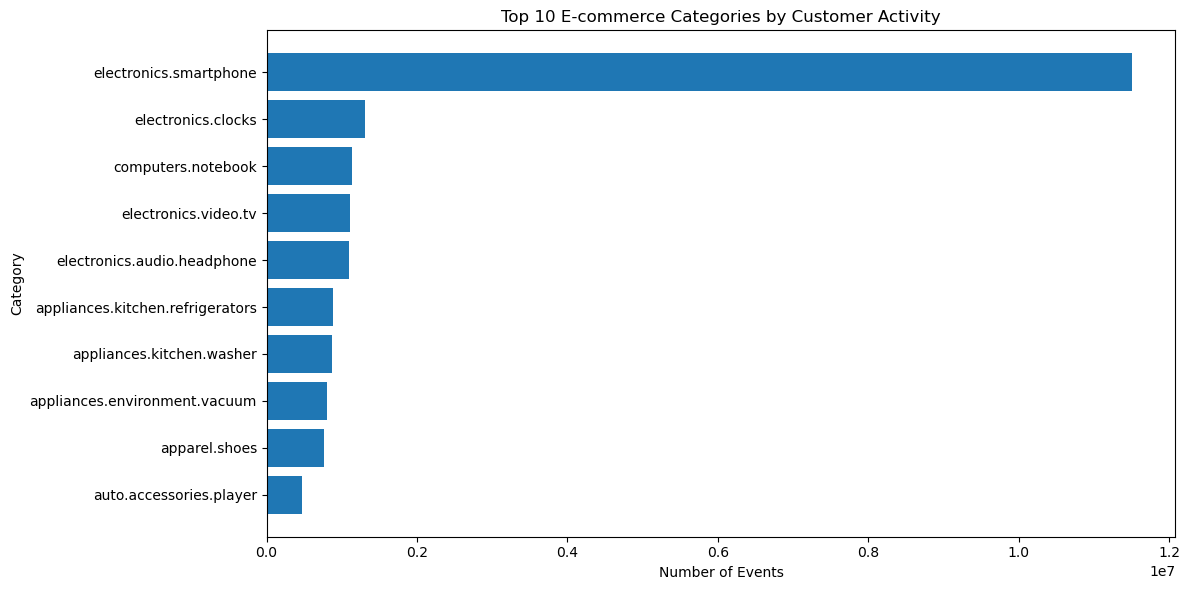

In [13]:
top_categories = category_counts.limit(10).toPandas()

plt.figure(figsize=(12, 6))
plt.barh(top_categories["category_code"], top_categories["count"])
plt.xlabel("Number of Events")
plt.ylabel("Category")
plt.title("Top 10 E-commerce Categories by Customer Activity")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [14]:
from pyspark.sql.functions import col, sum

missing_values = df.select(
    *[
        sum(col(c).isNull().cast("int")).alias(c)
        for c in df.columns
    ]
)

missing_values.show()

+----------+----------+----------+-----------+-------------+-------+-----+-------+------------+
|event_time|event_type|product_id|category_id|category_code|  brand|price|user_id|user_session|
+----------+----------+----------+-----------+-------------+-------+-----+-------+------------+
|         0|         0|         0|          0|     13515609|6113008|    0|      0|           2|
+----------+----------+----------+-----------+-------------+-------+-----+-------+------------+



In [15]:
df.createOrReplaceTempView("ecommerce_events")

spark_sql_result = spark.sql("""
    SELECT event_type, COUNT(*) AS total_events
    FROM ecommerce_events
    GROUP BY event_type
    ORDER BY total_events DESC
""")

spark_sql_result.show()

+----------+------------+
|event_type|total_events|
+----------+------------+
|      view|    40779399|
|      cart|      926516|
|  purchase|      742849|
+----------+------------+



In [1]:
from pyspark.sql import SparkSession

# Restart the Spark connection after the container restart.
spark = SparkSession.builder \
    .appName("Ecommerce_Big_Data_Analysis") \
    .getOrCreate()

print("Spark version:", spark.version)

Spark version: 3.5.0


In [2]:
# Load the e-commerce dataset from HDFS.
df = spark.read.csv(
    "hdfs://namenode:9000/ecommerce/input/2019-Oct.csv",
    header=True,
    inferSchema=True
)

df.printSchema()

root
 |-- event_time: timestamp (nullable = true)
 |-- event_type: string (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- category_id: long (nullable = true)
 |-- category_code: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- price: double (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- user_session: string (nullable = true)



In [3]:
# Take a small sample of the dataset for the machine learning stage.
# This reduces the computational load while keeping the analysis representative.
ml_sample = df.sample(
    withReplacement=False,
    fraction=0.01,
    seed=42
)

print("Sample records:", ml_sample.count())

Sample records: 425322


In [4]:
from pyspark.sql.functions import col, sum, avg, when

# Create user-level features from the sampled data.
# Views and cart actions are used as input features.
# Purchase activity is converted into the target label.
user_features = (
    ml_sample.groupBy("user_id")
    .agg(
        sum(when(col("event_type") == "view", 1).otherwise(0)).alias("view_count"),
        sum(when(col("event_type") == "cart", 1).otherwise(0)).alias("cart_count"),
        avg("price").alias("average_price"),
        sum(when(col("event_type") == "purchase", 1).otherwise(0)).alias("purchase_count")
    )
    .withColumn(
        "label",
        when(col("purchase_count") > 0, 1.0).otherwise(0.0)
    )
    .select(
        "user_id",
        "view_count",
        "cart_count",
        "average_price",
        "label"
    )
)

user_features.show(10)

+---------+----------+----------+-------------+-----+
|  user_id|view_count|cart_count|average_price|label|
+---------+----------+----------+-------------+-----+
|515772044|         1|         0|       128.45|  0.0|
|548068978|         1|         0|        64.09|  0.0|
|514569249|         1|         0|       377.14|  0.0|
|541099477|         1|         0|      1012.19|  0.0|
|544579345|         1|         0|      1466.91|  0.0|
|533895654|         5|         0|       50.326|  0.0|
|550223777|         1|         0|       257.15|  0.0|
|555494776|         1|         0|        50.32|  0.0|
|515565090|         1|         0|        22.62|  0.0|
|512614935|         1|         0|        72.05|  0.0|
+---------+----------+----------+-------------+-----+
only showing top 10 rows



In [5]:
from pyspark.ml.feature import VectorAssembler

# Combine the input variables into a single feature vector for Spark MLlib.
assembler = VectorAssembler(
    inputCols=["view_count", "cart_count", "average_price"],
    outputCol="features"
)

ml_data = assembler.transform(user_features)

# Keep only the columns needed for machine learning.
ml_data = ml_data.select("features", "label")

ml_data.show(10, truncate=False)

+-----------------+-----+
|features         |label|
+-----------------+-----+
|[1.0,0.0,128.45] |0.0  |
|[1.0,0.0,64.09]  |0.0  |
|[1.0,0.0,377.14] |0.0  |
|[1.0,0.0,1012.19]|0.0  |
|[1.0,0.0,1466.91]|0.0  |
|[5.0,0.0,50.326] |0.0  |
|[1.0,0.0,257.15] |0.0  |
|[1.0,0.0,50.32]  |0.0  |
|[1.0,0.0,22.62]  |0.0  |
|[1.0,0.0,72.05]  |0.0  |
+-----------------+-----+
only showing top 10 rows



In [6]:
from pyspark.ml.classification import LogisticRegression

# Split the prepared data into training and testing sets.
# 80% is used to train the model and 20% to evaluate it.
train_data, test_data = ml_data.randomSplit(
    [0.8, 0.2],
    seed=42
)

# Create a logistic regression classification model.
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label"
)

# Train the model using the training data.
lr_model = lr.fit(train_data)

# Generate predictions for the test data.
predictions = lr_model.transform(test_data)

predictions.select(
    "features",
    "label",
    "prediction",
    "probability"
).show(10, truncate=False)

+---------------+-----+----------+----------------------------------------+
|features       |label|prediction|probability                             |
+---------------+-----+----------+----------------------------------------+
|[0.0,0.0,4.35] |1.0  |1.0       |[0.4618632709869042,0.5381367290130958] |
|[0.0,0.0,8.75] |1.0  |1.0       |[0.4618054210949115,0.5381945789050885] |
|[0.0,0.0,8.88] |1.0  |1.0       |[0.4618037119091933,0.5381962880908067] |
|[0.0,0.0,12.84]|1.0  |1.0       |[0.46175164791314655,0.5382483520868535]|
|[0.0,0.0,16.75]|1.0  |1.0       |[0.461700242109343,0.538299757890657]   |
|[0.0,0.0,19.02]|1.0  |1.0       |[0.46167039819275746,0.5383296018072425]|
|[0.0,0.0,22.58]|1.0  |1.0       |[0.46162359507074713,0.5383764049292529]|
|[0.0,0.0,23.14]|1.0  |1.0       |[0.4616162328434478,0.5383837671565521] |
|[0.0,0.0,27.61]|1.0  |1.0       |[0.46155746709385614,0.5384425329061439]|
|[0.0,0.0,28.06]|1.0  |1.0       |[0.46155155113796,0.53844844886204]     |
+-----------

In [7]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Evaluate the model using classification accuracy.
evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

accuracy = evaluator.evaluate(predictions)

print("Model Accuracy:", round(accuracy, 4))

Model Accuracy: 0.9913


In [8]:
# Calculate additional evaluation metrics for the classification model.
# These metrics provide a more detailed view of model performance than accuracy alone.

precision = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
).evaluate(predictions)

recall = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
).evaluate(predictions)

f1 = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
).evaluate(predictions)

print("Weighted Precision:", round(precision, 4))
print("Weighted Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))

Weighted Precision: 0.9914
Weighted Recall: 0.9913
F1 Score: 0.9903


In [9]:
# Create a confusion matrix by comparing actual labels with model predictions.
# This shows correct and incorrect classifications for each class.

confusion_matrix = (
    predictions
    .groupBy("label", "prediction")
    .count()
    .orderBy("label", "prediction")
)

confusion_matrix.show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|62502|
|  1.0|       0.0|  555|
|  1.0|       1.0|  902|
+-----+----------+-----+



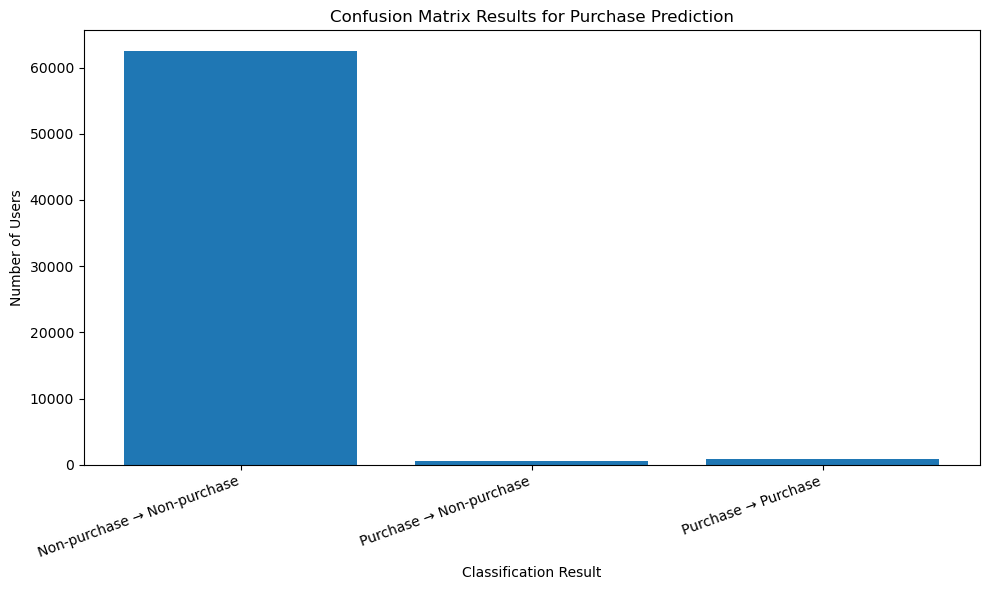

In [10]:
import matplotlib.pyplot as plt

# Convert the confusion matrix to a small Pandas DataFrame for plotting.
cm_data = confusion_matrix.toPandas()

# Create a simple bar chart showing actual vs predicted classes.
labels = [
    "Non-purchase → Non-purchase",
    "Purchase → Non-purchase",
    "Purchase → Purchase"
]

values = [
    cm_data.iloc[0]["count"],
    cm_data.iloc[1]["count"],
    cm_data.iloc[2]["count"]
]

plt.figure(figsize=(10, 6))
plt.bar(labels, values)

plt.xlabel("Classification Result")
plt.ylabel("Number of Users")
plt.title("Confusion Matrix Results for Purchase Prediction")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [11]:
# Check the distribution of the two target classes.
# Class 0 represents users without a purchase in the sample.
# Class 1 represents users with at least one purchase in the sample.

class_distribution = (
    user_features
    .groupBy("label")
    .count()
    .orderBy("label")
)

class_distribution.show()

+-----+------+
|label| count|
+-----+------+
|  0.0|313963|
|  1.0|  7173|
+-----+------+



In [12]:
from pyspark.sql.functions import when, avg, round

# Compare purchase rates between users who added products to their cart
# and users who did not add any products to their cart.
cart_conversion = (
    user_features
    .withColumn(
        "cart_user",
        when(col("cart_count") > 0, "Added to cart")
        .otherwise("No cart activity")
    )
    .groupBy("cart_user")
    .agg(
        round(avg("label") * 100, 2).alias("purchase_rate_percent")
    )
    .orderBy("purchase_rate_percent", ascending=False)
)

cart_conversion.show()

+----------------+---------------------+
|       cart_user|purchase_rate_percent|
+----------------+---------------------+
|   Added to cart|                 3.67|
|No cart activity|                 2.19|
+----------------+---------------------+



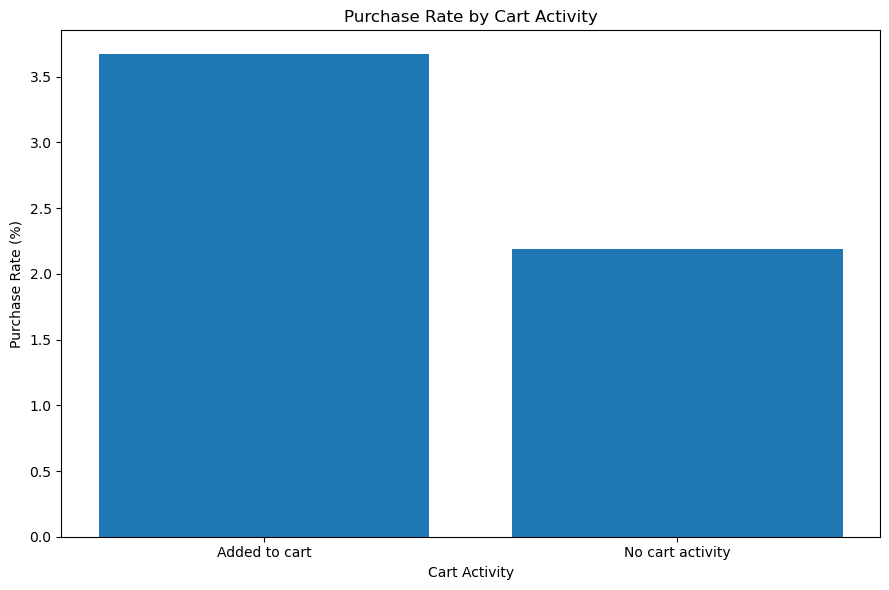

In [13]:
# Convert the Spark result to Pandas for visualisation.
conversion_data = cart_conversion.toPandas()

# Create a bar chart comparing purchase rates.
plt.figure(figsize=(9, 6))
plt.bar(
    conversion_data["cart_user"],
    conversion_data["purchase_rate_percent"]
)

plt.xlabel("Cart Activity")
plt.ylabel("Purchase Rate (%)")
plt.title("Purchase Rate by Cart Activity")
plt.tight_layout()
plt.show()

In [14]:
# Evaluate performance specifically for the purchase class (label = 1).
# This is more informative because purchase events are much less frequent
# than non-purchase events in the sample.

purchase_precision = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="precisionByLabel",
    metricLabel=1.0
).evaluate(predictions)

purchase_recall = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="recallByLabel",
    metricLabel=1.0
).evaluate(predictions)

purchase_f1 = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
).evaluate(
    predictions.filter(
        (col("label") == 1.0) | (col("prediction") == 1.0)
    )
)

print("Purchase Precision:", round(purchase_precision, 4))
print("Purchase Recall:", round(purchase_recall, 4))
print("Purchase F1 Score:", round(purchase_f1, 4))

PySparkTypeError: [NOT_COLUMN_OR_STR] Argument `col` should be a Column or str, got float.

In [15]:
# Use Python's built-in round function for the calculated metrics.
import builtins

print("Purchase Precision:", builtins.round(purchase_precision, 4))
print("Purchase Recall:", builtins.round(purchase_recall, 4))
print("Purchase F1 Score:", builtins.round(purchase_f1, 4))

Purchase Precision: 1.0
Purchase Recall: 0.6191
Purchase F1 Score: 0.7647


In [16]:
# Analyse the most purchased product categories.
# Only purchase events are included because the goal is to identify
# categories with the highest purchase activity.

purchase_categories = (
    df.filter(
        (col("event_type") == "purchase") &
        (col("category_code").isNotNull())
    )
    .groupBy("category_code")
    .count()
    .orderBy("count", ascending=False)
)

purchase_categories.show(10, truncate=False)

+--------------------------------+------+
|category_code                   |count |
+--------------------------------+------+
|electronics.smartphone          |338018|
|electronics.audio.headphone     |30503 |
|electronics.video.tv            |21565 |
|electronics.clocks              |17906 |
|appliances.kitchen.washer       |16148 |
|computers.notebook              |15590 |
|appliances.environment.vacuum   |12378 |
|appliances.kitchen.refrigerators|11218 |
|electronics.tablet              |5603  |
|auto.accessories.player         |4647  |
+--------------------------------+------+
only showing top 10 rows



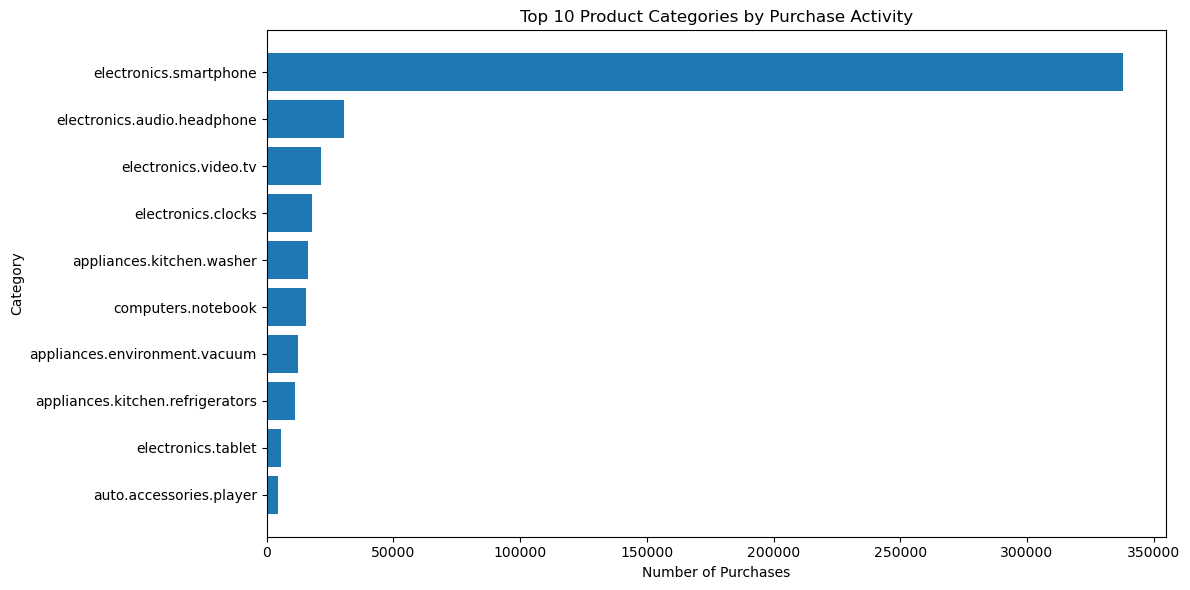

In [17]:
# Convert the top purchased categories to Pandas for visualisation.
top_purchase_categories = purchase_categories.limit(10).toPandas()

# Create a horizontal bar chart of the most purchased categories.
plt.figure(figsize=(12, 6))
plt.barh(
    top_purchase_categories["category_code"],
    top_purchase_categories["count"]
)

plt.xlabel("Number of Purchases")
plt.ylabel("Category")
plt.title("Top 10 Product Categories by Purchase Activity")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [18]:
# Check how the dataset is divided into Spark partitions.
# Partitions allow Spark to process large datasets in parallel.

partition_count = df.rdd.getNumPartitions()

print("Number of Spark partitions:", partition_count)

Number of Spark partitions: 43
